# Figure 5 — the inverse problem (predicting causal drivers)

Published panels **C/D/E/F** (per-dataset inverse ROC/PR for CRISPRi & CRISPRa; mean AUC 0.953/0.913), **H/I** (composite CIPHER linear-response vs log-fold-change margin AUROC/AUPRC), and **J/K/L/M** (sci-Plex drug identification: candidate log-likelihood, top-k, ROC, PR), reproduced with the packaged CIPHER inverse. A/B/G are schematics. Engine: `notebooks/src/run_fig5.py`.

In [1]:
import os, sys
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm','tqdm.auto','tqdm.notebook','tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception: pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ("main","suppl") else os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.run_fig5 import *
from src.logutil import route_logs
DATA_DIR = os.environ["CIPHER_DATA_DIR"]
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/fig5")
os.makedirs(OUTDIR, exist_ok=True)
route_logs("fig5_inverse")
import src.run_fig5 as R
R.__dict__.update({k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR","OUTDIR")})

[logs] verbose output -> ../../resources/repro/fig5/logs/fig5_inverse.log


## Panels C / D / E / F — per-dataset inverse ROC / PR

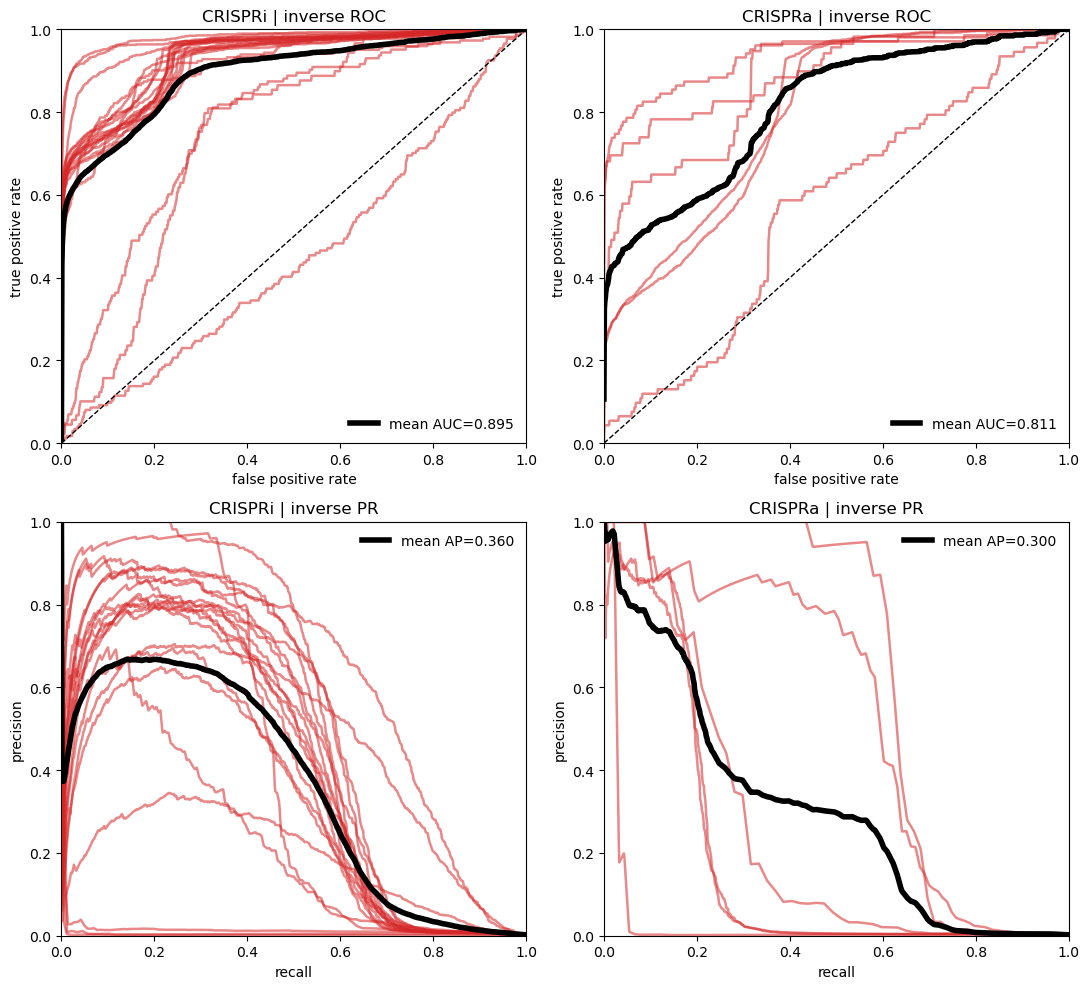

In [2]:
R.panels_cdef()

## CRISPRi identification (→ H/I composite)

In [3]:
R.run_crispri()

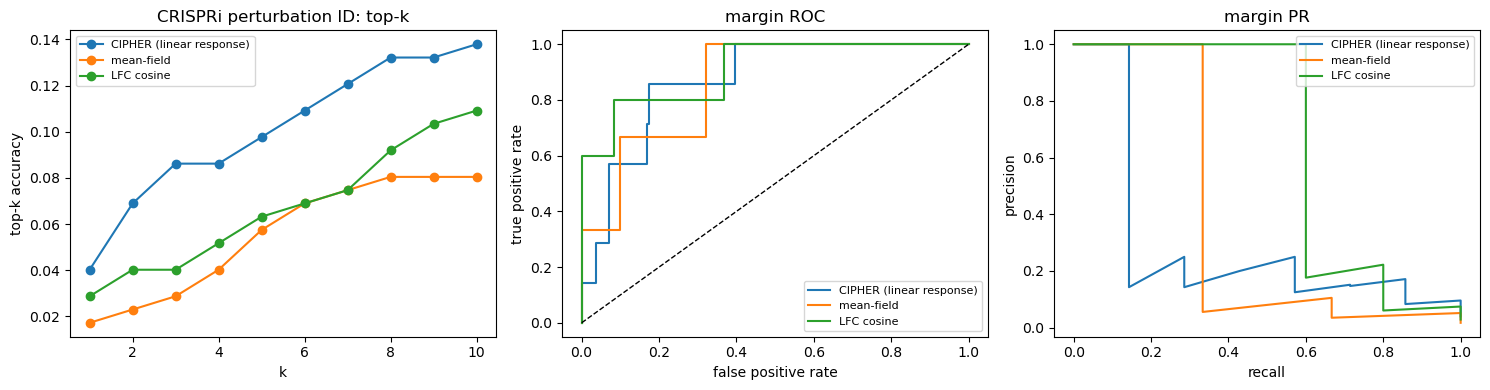

In [4]:
R.plot_crispri()

## sci-Plex drug identification — panels J / K / L / M (heavy: full-gene sci-Plex3)

In [5]:
R.run_sciplex()

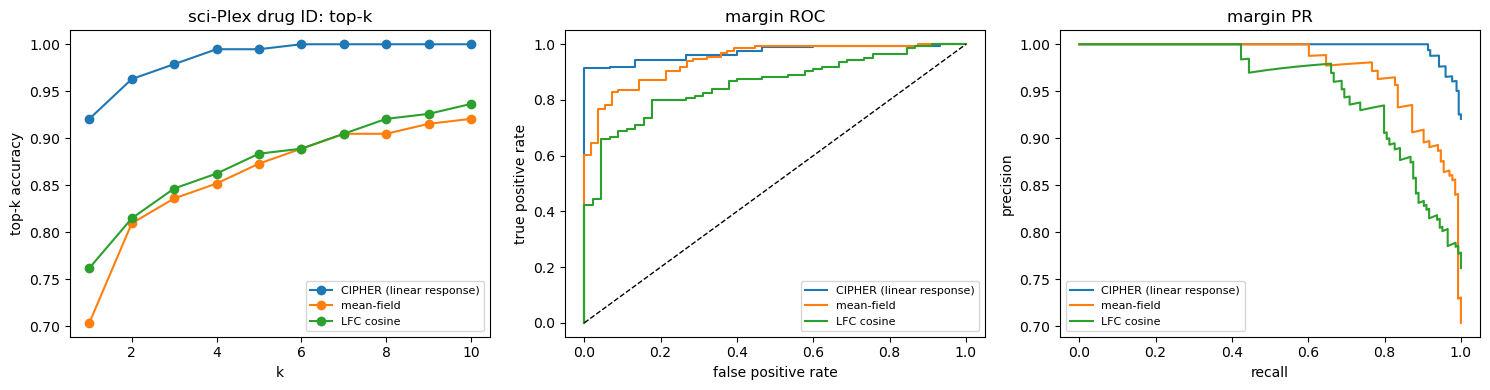

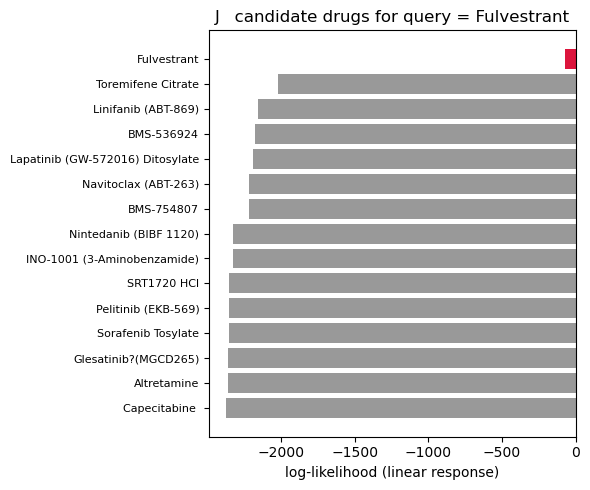

In [6]:
R.plot_sciplex()

## Panels H / I — composite margin AUROC / AUPRC (CIPHER vs LFC)

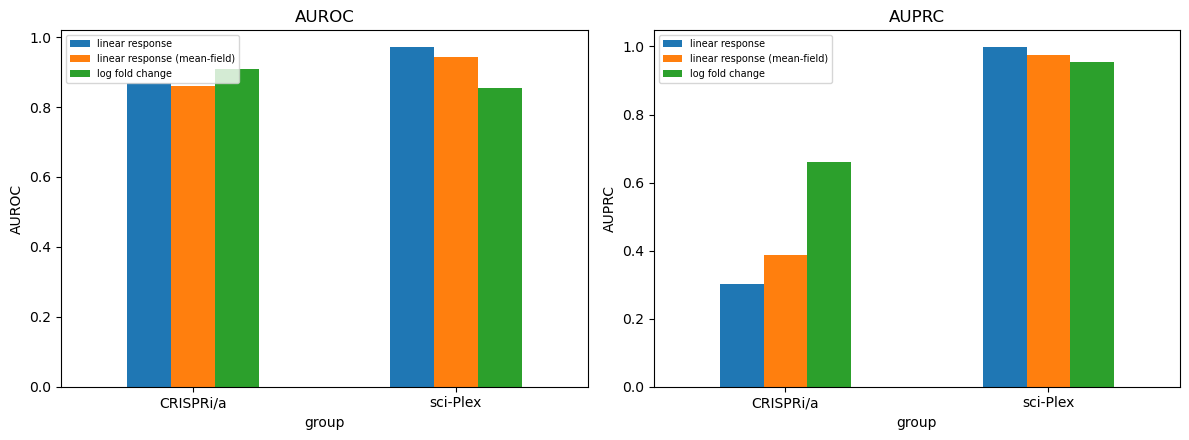

,group,method,AUROC,AUPRC
0,CRISPRi/a,linear response,0.869119,0.302691
1,CRISPRi/a,linear response (mean-field),0.859649,0.385662
2,CRISPRi/a,log fold change,0.910059,0.659370
3,sci-Plex,linear response,0.970881,0.997525
4,sci-Plex,linear response (mean-field),0.942938,0.976227
5,sci-Plex,log fold change,0.855864,0.954257


In [7]:
R.panels_hi_composite()